## Import all the core libraries 

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


## Load the csv data into the df variable

In [7]:

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("../data/raw/raw.csv")

## Move to general Data Exploration

In [14]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [16]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [17]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [18]:
df["isFlaggedFraud"].value_counts()


isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.shape

(6362620, 11)

In [ ]:
(df["isFraud"].value_counts()[1] / df.shape[0]) *100,2

np.float64(0.12908204481801522)

Meaning only 0.12% of the person are fraud so we know we need to balance it 

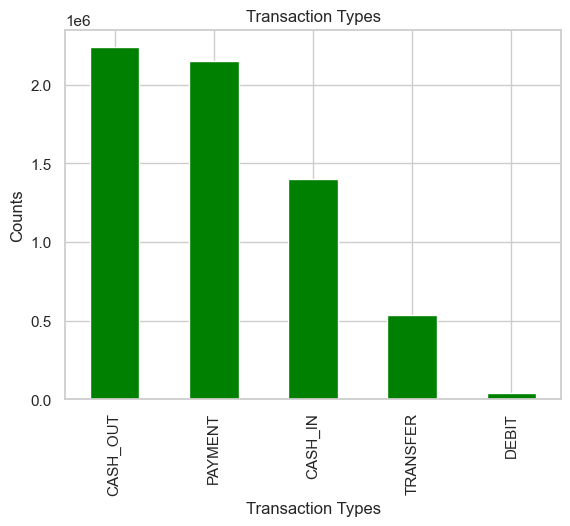

In [22]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types",color="green")
plt.xlabel("Transaction Types")
plt.ylabel("Counts")
plt.show()

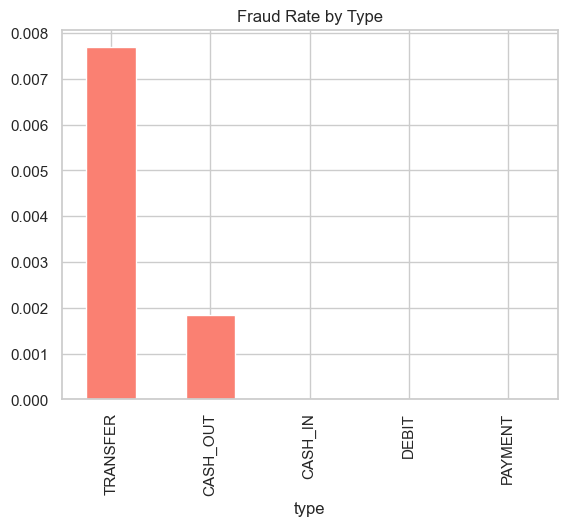

In [23]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending= False)
fraud_by_type.plot(kind="bar",title="Fraud Rate by Type",color="salmon")
plt.show()

In [24]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

Text(0.5, 1.0, 'Transaction')

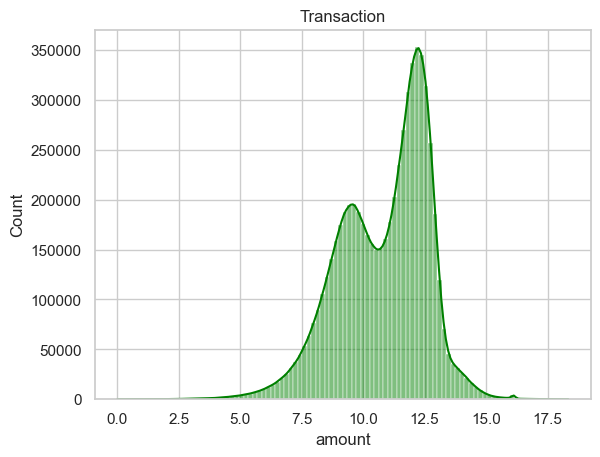

In [26]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction")

This looks pretty interesting as well 
Now lets look at the relationship between the  fraud and the amount as well

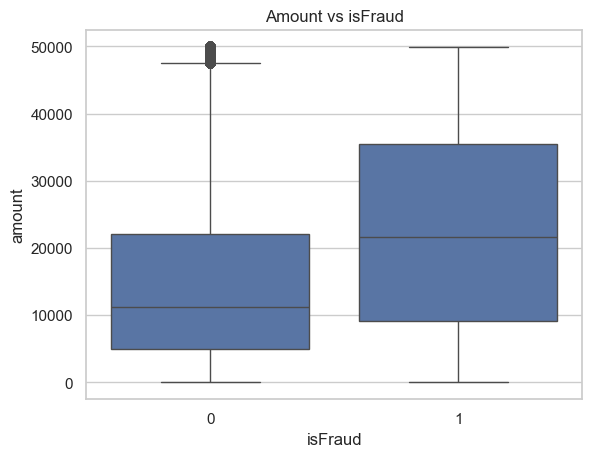

In [25]:
sns.boxplot(data=df[df["amount"]< 50000], x = "isFraud", y="amount")
plt.title("Amount vs isFraud")
plt.show()